In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from utils import neural_utils as nu
from mpl_toolkits import mplot3d
import math



In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# setup data 

# Domain : [0,1]^2 x [0,1]
# IC: u(x, y, 0) = sin(pi x)sin(pi y)
# BC: Dirichlet B(x,y, t) = 0 on boundary

# generate data

# can parametrize boundary with 2d rectangle

N_boundary = 200

def boundary_map(s):
    """
    s: shape (N, 1), values in [0, 1]
    returns x, y on boundary of [0,1]^2
    """
    s = s.view(-1, 1)
    q = 4 * s  # now q in [0, 4]

    x = torch.empty_like(q)
    y = torch.empty_like(q)

    m1 = (q >= 0) & (q < 1)
    m2 = (q >= 1) & (q < 2)
    m3 = (q >= 2) & (q < 3)
    m4 = (q >= 3) & (q <= 4)

    # left edge: x=0, y=q
    x[m1] = 0
    y[m1] = q[m1]

    # top edge: x=q-1, y=1
    x[m2] = q[m2] - 1
    y[m2] = 1

    # right edge: x=1, y=3-q
    x[m3] = 1
    y[m3] = 3 - q[m3]

    # bottom edge: x=4-q, y=0
    x[m4] = 4 - q[m4]
    y[m4] = 0

    return x, y

z = torch.rand(N_boundary,2, device=device)
s = z[:, 0:1]      
t = z[:, 1:2]  

x, y = boundary_map(s)

X_b = torch.cat([x, y, t], dim=1)
U_b = torch.zeros_like(x)

N_initial = 200

def initial(X):
    return torch.sin(torch.pi * X[:,0:1])*torch.sin(torch.pi * X[:,1:2])

x_init = torch.rand(N_initial, 2, device=device)
t = torch.zeros(N_initial,1, device=device)
X_init = torch.cat([x_init,t], dim = 1)
U_init = initial(X_init)

In [11]:
# Sample collocation points
N_col = 1000
X_col = nu.sample(dim=3, N=N_col, domain_map=nu.identity_map, device=device)

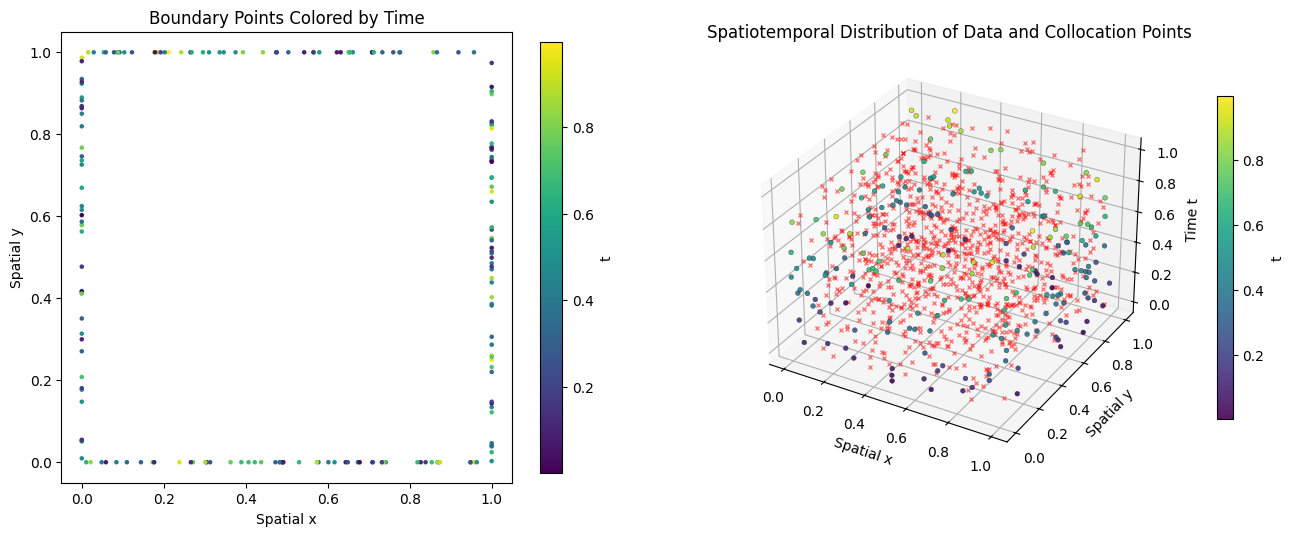

<Figure size 500x500 with 0 Axes>

In [12]:
x = X_b[:, 0].detach().cpu().numpy()
y = X_b[:, 1].detach().cpu().numpy()
t = X_b[:, 2].detach().cpu().numpy()

x_c = X_col[:, 0].detach().cpu().numpy()
y_c = X_col[:, 1].detach().cpu().numpy()
t_c = X_col[:, 2].detach().cpu().numpy()

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121)                  
ax2 = fig.add_subplot(122, projection='3d')

plt.figure(figsize=(5,5))
left  = ax1.scatter(x, y, c=t, s=5, cmap='viridis')
ax1.set_aspect('equal')
ax1.set_title("Boundary Points Colored by Time")
ax1.set_xlabel('Spatial x')
ax1.set_ylabel('Spatial y')

cbar1 = fig.colorbar(left, ax=ax1, pad=0.05, shrink=0.8)
cbar1.set_label("t")

ax2.plot3D(x_c, y_c, t_c, marker="x", linestyle="", markersize=3, color="red", alpha=0.5)
right = ax2.scatter(x, y, t, c=t, marker="o", s=12, cmap='viridis', alpha=0.9, edgecolors='black', linewidths=0.2, label="Boundary/Data")
ax2.set_xlabel('Spatial x')
ax2.set_ylabel('Spatial y')
ax2.set_zlabel('Time t')
ax2.set_title("Spatiotemporal Distribution of Data and Collocation Points")

cbar2 = fig.colorbar(right, ax=ax2, pad=0.1, shrink=0.6)
cbar2.set_label('t')
plt.tight_layout()
plt.show()

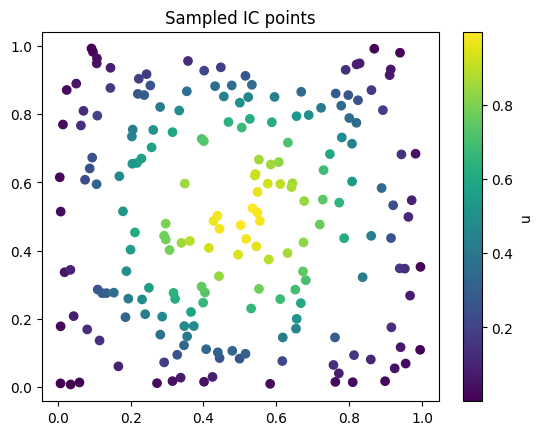

In [13]:
x = x_init[:, 0].detach().cpu().numpy()
y = x_init[:, 1].detach().cpu().numpy()
u = U_init.squeeze().detach().cpu().numpy()

plt.scatter(x, y, c=u, cmap='viridis')
plt.colorbar(label="u")
plt.title("Sampled IC points")
plt.show()

In [6]:
model = nu.FCN(3,1,20,5).to(device)

model



FCN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [14]:
def make_heat_2d_residual(alpha):

    def residual_fn(X, u, grad_u):
        u_x = grad_u[:, 0:1]
        u_y = grad_u[:, 1:2]
        u_t = grad_u[:, 2:3]

        grad_u_x = nu.gradients(u_x, X)
        grad_u_y = nu.gradients(u_y, X)

        u_xx = grad_u_x[:, 0:1]
        u_yy = grad_u_y[:, 1:2]

        return u_t - alpha * (u_xx + u_yy)

    return residual_fn

residual_fn = make_heat_2d_residual(0.1)

def analytic(alpha, x,y, t):
    return torch.exp(-2 * alpha * math.pi**2 * t) * torch.sin(math.pi * x) * torch.sin(math.pi * y)

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X_data = torch.cat([X_b,X_init], dim = 0)
U_data = torch.cat([U_b, U_init], dim=0)

losses, losses_data, losses_phys, *_ = nu.train(50000, optimizer, X_data, U_data, model, residual_fn, 1, X_col)

0 0.11048326641321182 0.110341876745224 0.0001413873105775565
100 0.08174650371074677 0.08156325668096542 0.0001832470006775111
200 0.08040566742420197 0.07880396395921707 0.0016017014859244227
300 0.08015935122966766 0.07835590839385986 0.0018034444656223059
400 0.07985394448041916 0.07801233977079391 0.0018416011007502675
500 0.07938849180936813 0.077537402510643 0.0018510896479710937
600 0.07856482267379761 0.07674568891525269 0.0018191355047747493
700 0.0768381878733635 0.07511428743600845 0.0017239040462300181
800 0.07245418429374695 0.07091724127531052 0.0015369463944807649
900 0.06263308227062225 0.06060709059238434 0.0020259928423911333
1000 0.05306960269808769 0.04958256706595421 0.003487036330625415
1100 0.04235360026359558 0.039385534822940826 0.0029680649749934673
1200 0.03234083205461502 0.02978222817182541 0.002558602951467037
1300 0.025387665256857872 0.022954965010285378 0.002432700712233782
1400 0.021068857982754707 0.018715733662247658 0.002353124786168337
1500 0.0184

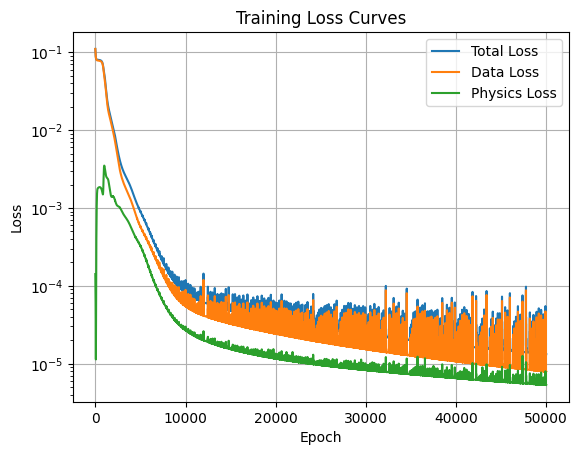

In [11]:
epochs = range(len(losses))

plt.plot(epochs, losses, label='Total Loss')
plt.plot(epochs, losses_data, label='Data Loss')
plt.plot(epochs, losses_phys, label='Physics Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training Loss Curves')

plt.yscale('log')
plt.legend()
plt.grid()

plt.show()

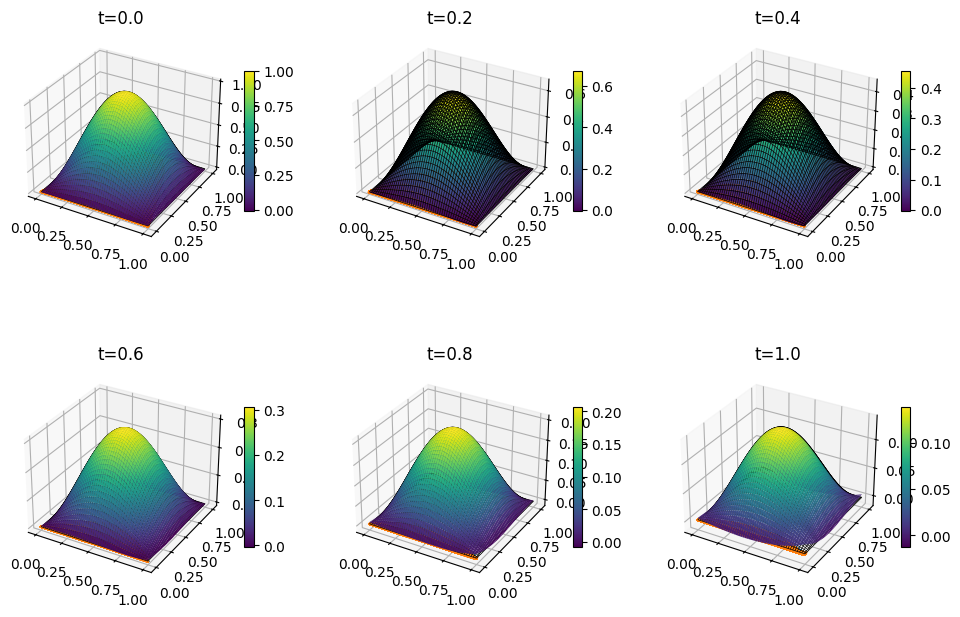

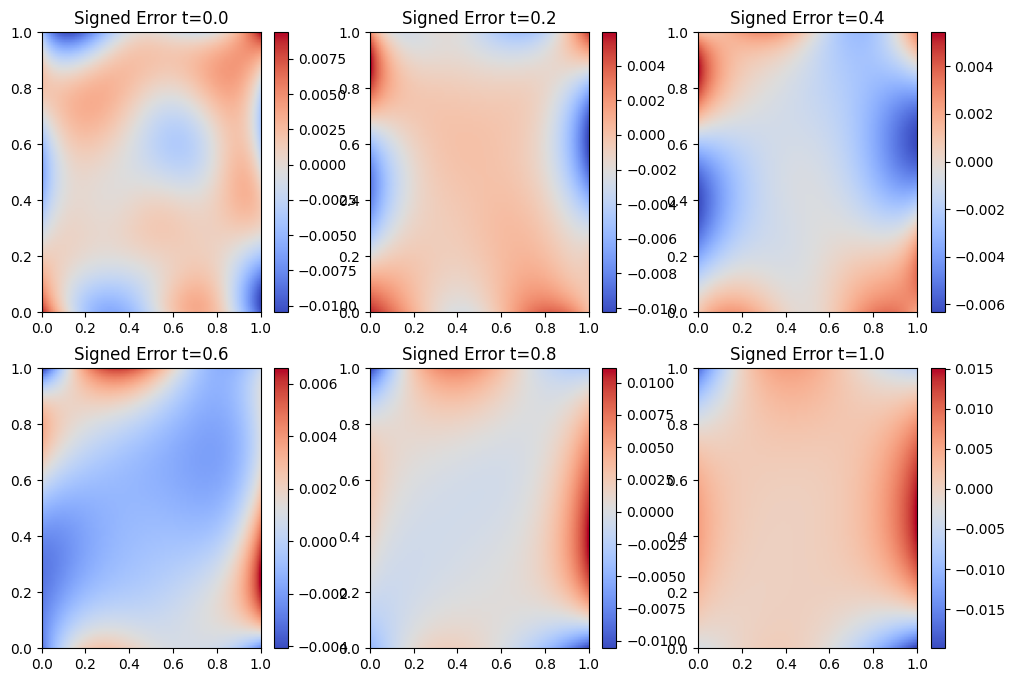

In [12]:
# time slice visualization

N_grid = 100
x = torch.linspace(0,1, N_grid, device=device)
y = torch.linspace(0,1, N_grid, device=device)


times = [0, 0.2, 0.4, 0.6, 0.8,1]

fig1, axes1 = plt.subplots(2,3, figsize=(12,8), subplot_kw={"projection": "3d"})
axes1 = axes1.flatten()

fig2, axes2 = plt.subplots(2,3, figsize=(12,8))
axes2 = axes2.flatten()

for i,t in enumerate(times):
    X,Y= torch.meshgrid(x,y, indexing="ij")

    T = torch.full_like(X, t)

    XYT = torch.stack([X.reshape(-1),Y.reshape(-1),T.reshape(-1)], dim=1)

    with torch.no_grad():
        u_pred = model(XYT).reshape(N_grid,N_grid).detach().cpu().numpy()

    u_true = analytic(0.1, X,Y,T).detach().cpu().numpy()

    ax1 = axes1[i]

    # // TODO add titles and labels
    surf = ax1.plot_surface(X, Y, u_pred, cmap="viridis")
    fig1.colorbar(surf, ax=ax1, shrink=0.5, aspect=15)
    ax1.plot_wireframe(X, Y, u_true,
    color='black',
    linewidth=0.5)

    ax1.plot(x, u_true, '--', label='true')
    ax1.plot(x, u_pred, '-', label='pred')

    ax1.set_title(f"t={t:.1f}")
    ax1.grid()

    ax2 = axes2[i]

    plot = ax2.imshow(u_true - u_pred, 
    cmap="coolwarm",
    extent=[0,1,-0,1],
    origin='lower',
    aspect='auto',
    )

    ax2.set_title(f"Signed Error t={t:.1f}")
    fig2.colorbar(plot, ax=ax2)





In [ ]:
embeddings = {}
for layer, activations in layer_activations.items():
    tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
    embedding = tsne.fit(activations.cpu().numpy())
    embeddings[layer] = embedding
    print(f"Layer {layer} t-SNE embedding shape: {embedding.shape}")

Layer net.1 t-SNE embedding shape: (125000, 2)
Layer net.3 t-SNE embedding shape: (125000, 2)
Layer net.5 t-SNE embedding shape: (125000, 2)
Layer net.7 t-SNE embedding shape: (125000, 2)
Layer net.9 t-SNE embedding shape: (125000, 2)


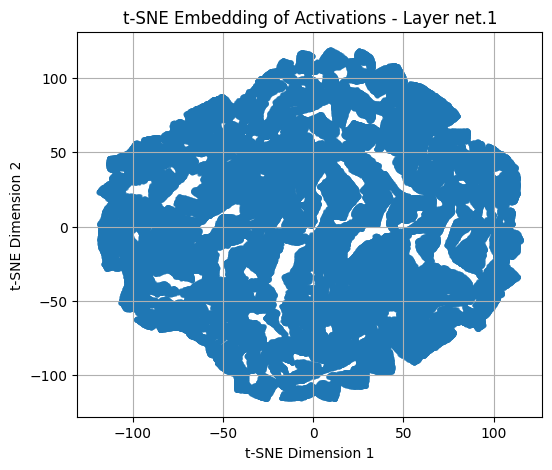

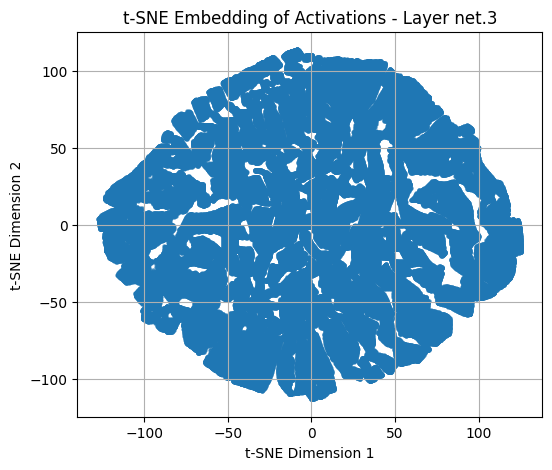

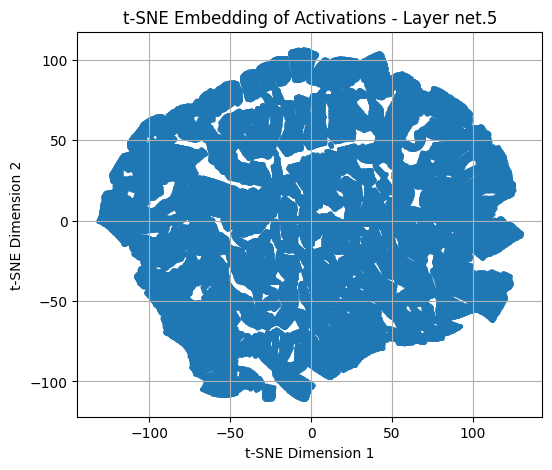

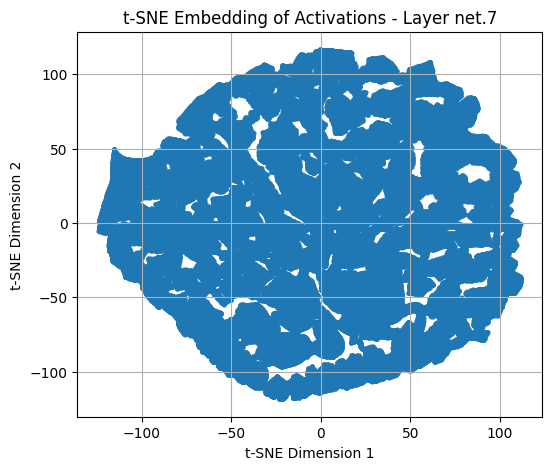

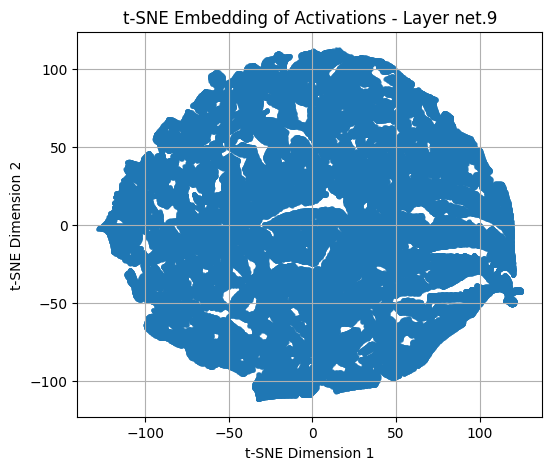

In [27]:
for layer, embedding in embeddings.items():
    plt.figure(figsize=(6, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=5, alpha=0.7)
    plt.title(f"t-SNE Embedding of Activations - Layer {layer}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid()
    plt.show()

In [ ]:
save_dict = {"activations": activations, "embeddings": embeddings, "X_data": X_data }

current_file_dir = Path.cwd()

project_root = current_file_dir.parent

output_folder = project_root / "embeddings"
output_folder.mkdir(parents=True, exist_ok=True)
    
save_path = output_folder / "heat2Dembeddings.pt"

In [25]:
del tsne

In [ ]:
torch.save(save_dict, save_path)

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\victo\\AppData\\Local\\Temp\\tmpdufqk6vn\\tmp.ann'